# 06 - Summary visuals

This notebook produces the plots that summarise the whole project in a
form someone new to the repo can read at a glance. Nothing new happens
here: everything is drawn from data already produced by notebooks 03-05.

**Four plots**
1. **Hero** - score-vs-cycle for four representative engines with the
   IF threshold line, DBSCAN noise markers, and the failure line.
2. **Feature space over time** - the 20-dimensional feature matrix
   projected to 2D via PCA and coloured by RUL.
3. **Lead-time distribution** - histogram plus reverse CDF, both detectors.
4. **Per-engine detection heatmap** - a 249 x 2 grid showing when each
   detector fired for each engine, engines sorted by lifespan.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

import pickle
with open(ROOT / "models" / "FD004" / "isolation_forest.pkl", "rb") as f:
    if_bundle = pickle.load(f)
IF_THRESHOLD = if_bundle["threshold"]

eval_df = pd.read_csv(ROOT / "data" / "eval_merged.csv")
feat = pd.read_csv(ROOT / "data" / "features_train.csv")
feature_cols = [c for c in feat.columns
                if c not in ("unit", "cycle", "regime", "rul")]
print(f"eval_df: {len(eval_df):,} rows")
print(f"feat   : {len(feat):,} rows, {len(feature_cols)} features")
print(f"IF threshold: {IF_THRESHOLD:.3f}")

eval_df: 61,249 rows
feat   : 61,249 rows, 20 features
IF threshold: 0.503


## 1. Hero plot: score-vs-cycle for four representative engines

Pick two long-lived and two short-lived engines. For each, plot the IF
anomaly score over the engine's life, overlay the IF threshold as a dashed
line, mark cycles DBSCAN called noise as red dots, and put a vertical line
at the failure cycle. This is the single most compact way to show what the
two detectors are doing.

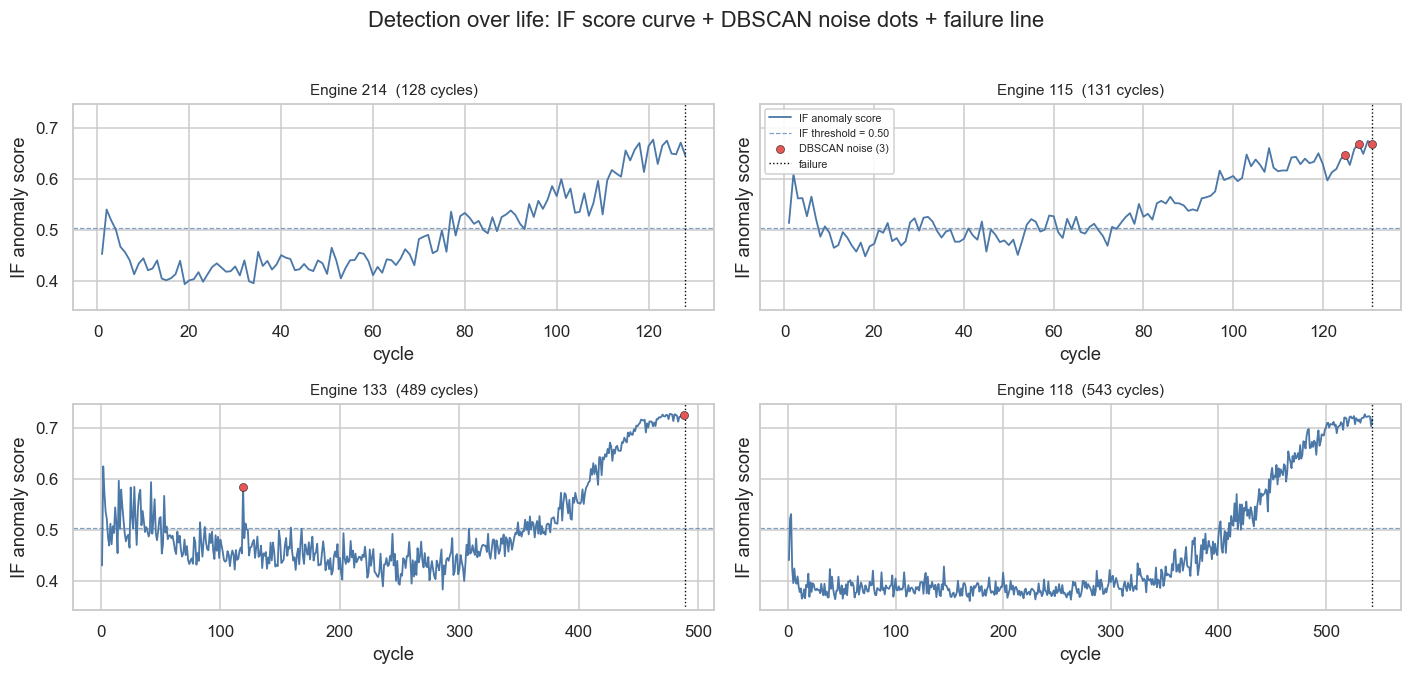

In [2]:
def hero_panel(ax, eval_df, unit, if_threshold):
    sub = eval_df[eval_df["unit"] == unit].sort_values("cycle")
    ax.plot(sub["cycle"], sub["if_score"], color="#4c78a8",
            linewidth=1.2, label="IF anomaly score")
    ax.axhline(if_threshold, color="#4c78a8", linestyle="--",
               linewidth=0.8, alpha=0.7, label=f"IF threshold = {if_threshold:.2f}")
    noise = sub[sub["dbscan_noise"] == 1]
    if len(noise):
        ax.scatter(noise["cycle"], noise["if_score"], s=28,
                   color="#e45756", edgecolor="black", linewidth=0.3,
                   label=f"DBSCAN noise ({len(noise)})", zorder=5)
    ax.axvline(sub["cycle"].max(), color="black", linestyle=":",
               linewidth=0.9, label="failure")
    ax.set_title(f"Engine {unit}  ({sub['cycle'].max()} cycles)", fontsize=10)
    ax.set_xlabel("cycle")
    ax.set_ylabel("IF anomaly score")

lifespans = eval_df.groupby("unit")["cycle"].max().sort_values()
short_units = lifespans.head(2).index.tolist()
long_units = lifespans.tail(2).index.tolist()
engines = short_units + long_units

fig, axes = plt.subplots(2, 2, figsize=(13, 6), sharey=True)
for ax, u in zip(axes.flatten(), engines):
    hero_panel(ax, eval_df, u, IF_THRESHOLD)
axes[0, 1].legend(loc="upper left", fontsize=7, framealpha=0.9)
fig.suptitle(
    "Detection over life: IF score curve + DBSCAN noise dots + failure line",
    y=1.02,
)
fig.tight_layout()
plt.show()

**Reading the plot.** Each panel is one engine's life from left to
right. The blue line is the IF score, the dashed line is the threshold,
red dots mark cycles DBSCAN flagged as noise, and the dotted vertical line
is failure. In a well-behaved engine the blue line stays below the
threshold for most of life and crosses it well before failure; the red
DBSCAN dots cluster near the end of life; the two detectors agree on the
"something is wrong" phase but disagree on when to start worrying.

## 2. Feature space over time (PCA coloured by RUL)

Every cycle of every engine is a point in 20-dimensional feature space.
PCA collapses that to 2D. Colouring each point by its RUL (cool = far
from failure, warm = close) reveals how engines trace out a path from
"healthy" to "degraded".

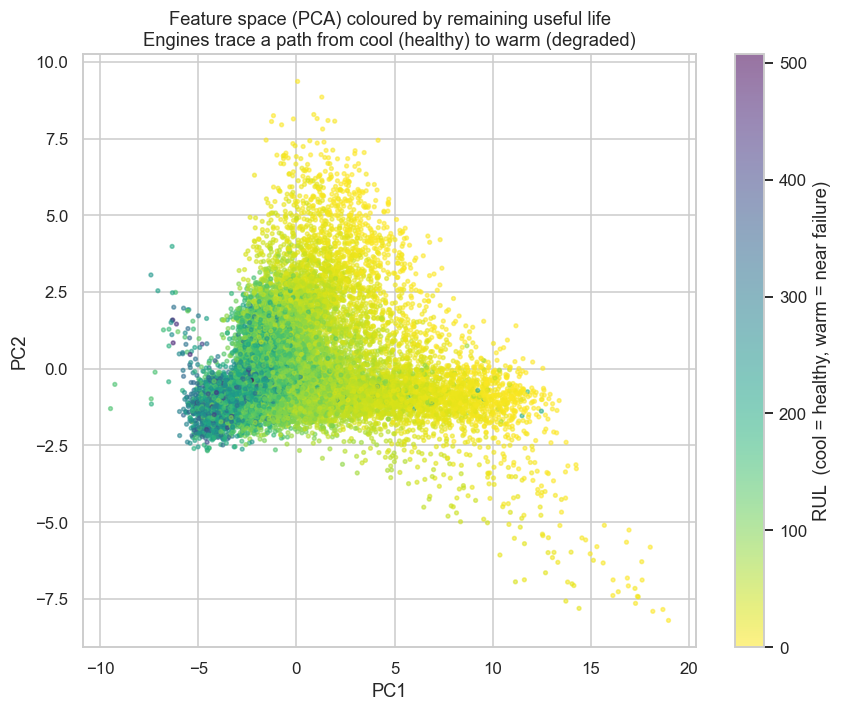

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

WARMUP = 30
warmed = feat[feat["cycle"] > WARMUP].reset_index(drop=True)
X = StandardScaler().fit_transform(warmed[feature_cols].values)
XY = PCA(n_components=2, random_state=0).fit_transform(X)
warmed["pc1"] = XY[:, 0]
warmed["pc2"] = XY[:, 1]

# For visual clarity subsample so overplot does not swamp the pattern.
subsample = warmed.sample(n=min(20000, len(warmed)), random_state=0)

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(
    subsample["pc1"], subsample["pc2"], c=subsample["rul"],
    cmap="viridis_r", s=6, alpha=0.55,
)
plt.colorbar(sc, ax=ax, label="RUL  (cool = healthy, warm = near failure)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(
    "Feature space (PCA) coloured by remaining useful life\n"
    "Engines trace a path from cool (healthy) to warm (degraded)"
)
plt.show()

**Reading the plot.** A clean colour gradient across the point
cloud is the shape we want: healthy cycles cluster in one region, degraded
cycles drift into another. If the colours are mixed everywhere the
features are not separating healthy from degraded; if they form clean
bands with a smooth gradient, they are.

## 3. Lead-time distribution and reverse CDF

The reverse CDF answers the question a maintenance planner actually asks:
*"if I need X cycles of warning to schedule the pull, what fraction of
engines will I catch in time?"*

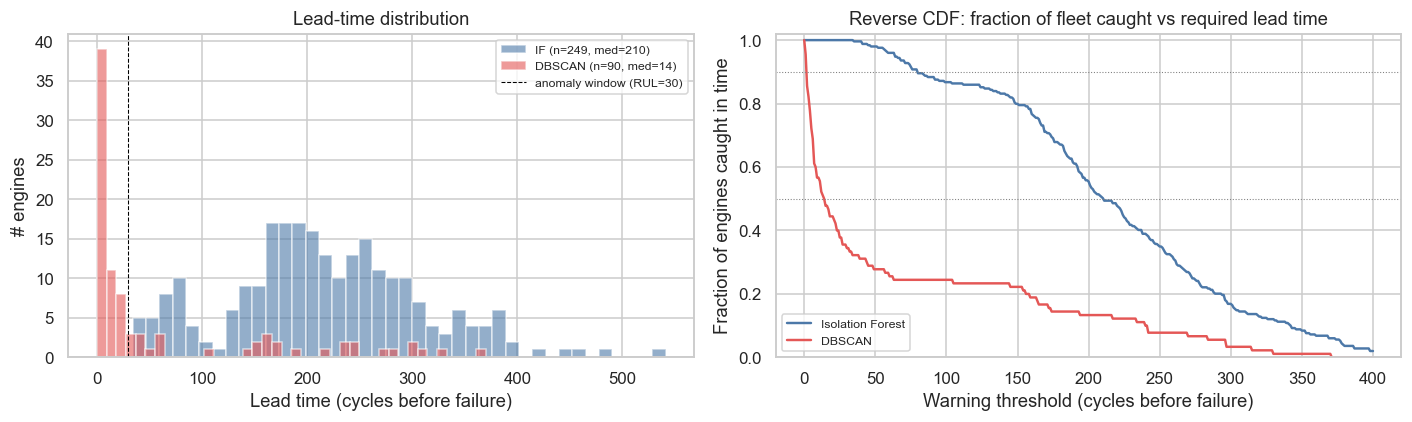

In [4]:
from src.evaluate import first_flag_lead_time

# Rebuild lead-time dataframes from the merged eval.
if_scores = eval_df.rename(columns={"if_score": "score"})
if_lead = first_flag_lead_time(if_scores, threshold=IF_THRESHOLD)

# DBSCAN: warmed-up rows only. Missing dbscan_noise means outside warmup.
db_scores = eval_df.dropna(subset=["dbscan_noise"]).copy()
db_scores["score"] = db_scores["dbscan_noise"].astype(float)
db_lead = first_flag_lead_time(db_scores, threshold=0.5)

# Reverse CDF: for each X, what fraction of engines have lead >= X?
def reverse_cdf(values, x_max=400):
    xs = np.arange(0, x_max + 1)
    ys = [(np.asarray(values) >= x).mean() for x in xs]
    return xs, ys

if_x, if_y = reverse_cdf(if_lead["lead_time_cycles"].values)
db_x, db_y = reverse_cdf(db_lead["lead_time_cycles"].values)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram (left).
axes[0].hist(if_lead["lead_time_cycles"], bins=40, alpha=0.6,
             color="#4c78a8", edgecolor="white",
             label=f"IF (n={len(if_lead)}, med={if_lead['lead_time_cycles'].median():.0f})")
axes[0].hist(db_lead["lead_time_cycles"], bins=40, alpha=0.6,
             color="#e45756", edgecolor="white",
             label=f"DBSCAN (n={len(db_lead)}, med={db_lead['lead_time_cycles'].median():.0f})")
axes[0].axvline(30, color="black", linestyle="--", linewidth=0.7,
                label="anomaly window (RUL=30)")
axes[0].set_xlabel("Lead time (cycles before failure)")
axes[0].set_ylabel("# engines")
axes[0].set_title("Lead-time distribution")
axes[0].legend(fontsize=8)

# Reverse CDF (right).
axes[1].plot(if_x, if_y, color="#4c78a8", linewidth=1.6, label="Isolation Forest")
axes[1].plot(db_x, db_y, color="#e45756", linewidth=1.6, label="DBSCAN")
axes[1].axhline(0.5, color="grey", linestyle=":", linewidth=0.7)
axes[1].axhline(0.9, color="grey", linestyle=":", linewidth=0.7)
axes[1].set_xlabel("Warning threshold (cycles before failure)")
axes[1].set_ylabel("Fraction of engines caught in time")
axes[1].set_title("Reverse CDF: fraction of fleet caught vs required lead time")
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

**Reading the reverse CDF.** Pick a warning threshold on the x-axis
(say, 100 cycles). Read up to a curve, then across to the y-axis. That
tells you what fraction of the fleet would have been caught with at least
that much warning. Higher curves are better. For most operational
questions IF's curve will sit well above DBSCAN's.

## 4. Per-engine detection heatmap

One row per engine (sorted by lifespan), two columns (IF, DBSCAN). Colour
each cell by the lead time in cycles. White = never flagged. This makes
the fleet-level story visible in one image.

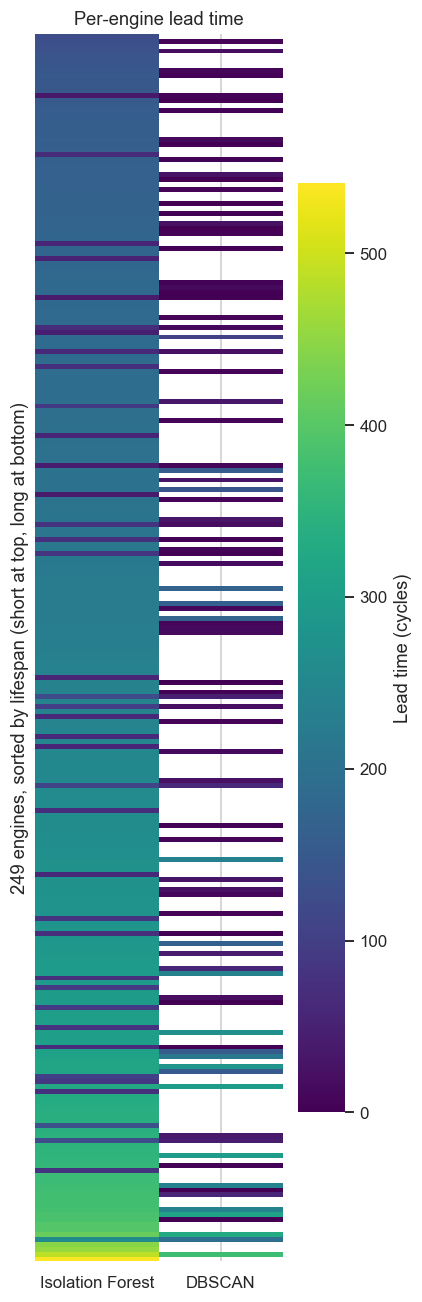

In [5]:
ls = eval_df.groupby("unit")["cycle"].max().sort_values()
unit_order = ls.index.tolist()

heat = pd.DataFrame(index=unit_order, columns=["Isolation Forest", "DBSCAN"], dtype=float)
for u in unit_order:
    heat.loc[u, "Isolation Forest"] = (
        if_lead["lead_time_cycles"].get(u, np.nan) if u in if_lead.index else np.nan
    )
    heat.loc[u, "DBSCAN"] = (
        db_lead["lead_time_cycles"].get(u, np.nan) if u in db_lead.index else np.nan
    )

fig, ax = plt.subplots(figsize=(4, 12))
sns.heatmap(
    heat, cmap="viridis", ax=ax, cbar_kws={"label": "Lead time (cycles)"},
    xticklabels=True, yticklabels=False,
)
ax.set_ylabel(f"249 engines, sorted by lifespan (short at top, long at bottom)")
ax.set_title("Per-engine lead time")
plt.tight_layout()
plt.show()

**Reading the heatmap.** Left column (IF) should be a mostly-uniform
column of moderate-to-high values with few white gaps: every engine gets
some warning. Right column (DBSCAN) will have many white cells (engines
DBSCAN never flagged) plus a scattering of cyan cells (engines caught
late). The contrast is a direct visual of the "IF broad and early, DBSCAN
precise and late" story.

## Conclusion

The four plots together tell the whole story of v2:

- **Hero panels.** IF gives a smooth anomaly-score curve that crosses its
  threshold well before failure on most engines; DBSCAN adds precise red
  dots close to the end.
- **PCA colour gradient.** The 20 hypothesis-driven features carve out a
  space where healthy cycles and degraded cycles are visibly separated.
- **Lead-time reverse CDF.** IF catches roughly all 249 engines with
  substantial warning (median ~200 cycles). DBSCAN catches about a third
  of the fleet, mostly late, but with high per-flag precision.
- **Detection heatmap.** The trade-off is legible at a glance: IF is a
  broad early-warning system, DBSCAN is a strict late confirmer.

**What this project became.** V1 was five detectors on four subsets with
184 features and a Streamlit dashboard. V2 is two detectors on one subset
with 20 justified features, evaluated by the metric that matches the
actual question. The v2 flow is a fifth as much code, easier to explain,
and produces the same kind of conclusion.

**What v2 does not include** (deliberately)
- No hyperparameter search. The chosen values are defensible defaults;
  tuning them is a natural follow-up.
- No test-set scoring. The training run-to-failure trajectories provide
  cleaner ground truth (per-cycle RUL) than the cut-off test set (only
  end-of-recording RUL). Extending to test: apply the same feature
  pipeline via `src.data.load_fd004('test')`, reuse the fitted KMeans and
  IF from disk. Left as a follow-up exercise.

**Where to read the numbers directly**
- Feature engineering: `notebooks/02_feature_engineering.ipynb`.
- Model training: `notebooks/03_train_iforest.ipynb`, `04_train_dbscan.ipynb`.
- Metrics: `notebooks/05_evaluate.ipynb`.